Loaded feature 1462 from: checkpoints\pseudotime_cells_clean_1462.pkl
Loaded feature 1476 from: checkpoints\pseudotime_cells_clean_1476.pkl
Selected 1462 examples:


,pseudotime_widths,path_background,path_dapi
obj_id,,,
7190001,"[8, 12, 22, 30, 25, 18, 14, 10, 9, 9, 8, 9, 9,...",C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...
4320001,"[20, 15, 11, 10, 9, 9, 8, 10, 10, 10, 9, 9, 8,...",C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...


Selected 1476 examples:


,pseudotime_widths,path_background,path_dapi
obj_id,,,
7560001,"[15, 12, 11, 11, 10, 8, 5, 4, 4, 5, 6, 7, 8, 8...",C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...
5170001,"[4, 5, 5, 7, 8, 8, 10, 10, 12, 19, 16, 12, 12,...",C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...


C:\Users\20212358\AppData\Local\Temp\ipykernel_22424\1340010476.py:348: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: Figure4_rotated_pseudolocation_fingerprints.png


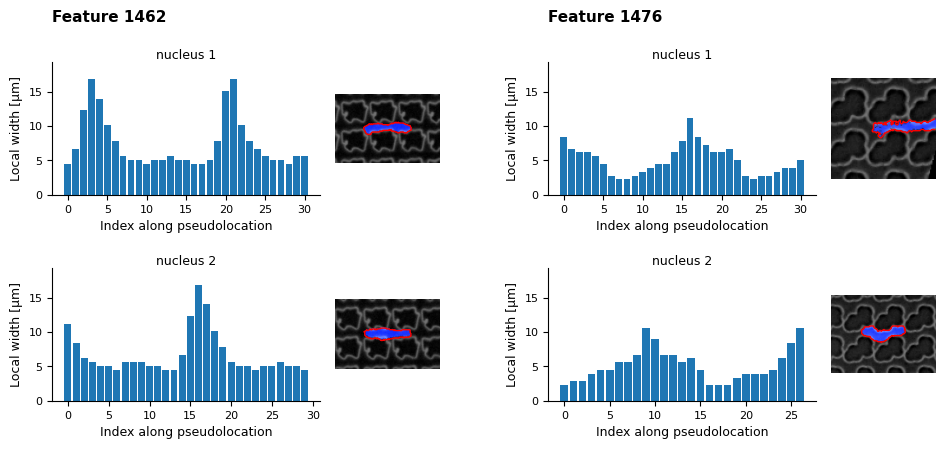

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Load dataframe for each feature
# ------------------------------------------------------------

def load_feature_dataframe(feature_id):
    """
    Looks for a cleaned pseudotime dataframe for one feature.
    Adjust the candidate filenames if your local names differ.
    """
    feature_id = str(feature_id)

    candidates = [
        f"checkpoints/pseudotime_cells_clean_{feature_id}.pkl",
        f"checkpoints/pseudotime_cells_{feature_id}.pkl",
        f"pseudotime_cells_clean_{feature_id}.pkl",
        f"pseudotime_cells_{feature_id}.pkl",
    ]

    for path in candidates:
        path = Path(path)
        if path.exists():
            print(f"Loaded feature {feature_id} from: {path}")
            return pd.read_pickle(path)

    # fallback: search recursively
    matches = list(Path(".").rglob(f"*{feature_id}*.pkl"))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find a pickle dataframe for feature {feature_id}. "
            f"Checked: {candidates}"
        )

    print(f"Loaded feature {feature_id} from: {matches[0]}")
    return pd.read_pickle(matches[0])


df1462 = load_feature_dataframe(1462)
df1476 = load_feature_dataframe(1476)


# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------

required_cols = ["pseudotime_widths", "path_background", "path_dapi"]

for name, df in [("1462", df1462), ("1476", df1476)]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"\nFeature {name} missing columns:")
        print(missing)
        print("\nAvailable path-like columns:")
        print([c for c in df.columns if "path" in c.lower()])
        print("\nAvailable pseudotime-like columns:")
        print([c for c in df.columns if "pseudo" in c.lower()])
        raise KeyError(f"Missing required columns in feature {name}: {missing}")


# ------------------------------------------------------------
# Select two example nuclei from each feature
# ------------------------------------------------------------

def profile_length(x):
    arr = parse_array(x, dtype=float)
    return len(arr)


def select_example_nuclei(df, n=2):
    """
    Selects visually useful nuclei:
    - has a valid pseudotime_widths profile
    - has existing image paths
    - prefers longer profiles, because they make clearer bar plots
    """
    df = df.copy()

    df["_profile_length"] = df["pseudotime_widths"].apply(profile_length)

    df = df[
        (df["_profile_length"] > 5)
        & df["path_background"].notna()
        & df["path_dapi"].notna()
    ].copy()

    # keep rows where image files exist
    df = df[
        df["path_background"].apply(lambda p: Path(p).exists())
        & df["path_dapi"].apply(lambda p: Path(p).exists())
    ].copy()

    if len(df) < n:
        raise ValueError(f"Only found {len(df)} usable nuclei, need {n}.")

    # choose examples with relatively long width profiles
    df = df.sort_values("_profile_length", ascending=False)

    return df.head(n)


df1462_examples = select_example_nuclei(df1462, n=2)
df1476_examples = select_example_nuclei(df1476, n=2)

print("Selected 1462 examples:")
display(df1462_examples[["pseudotime_widths", "path_background", "path_dapi"]])

print("Selected 1476 examples:")
display(df1476_examples[["pseudotime_widths", "path_background", "path_dapi"]])


# ------------------------------------------------------------
# Plot figure
# ------------------------------------------------------------

fig = plot_pseudolocation_fingerprint_figure(
    panels=[
        {
            "df": df1462_examples,
            "feature": "1462",
            "rotation_deg": 28.34
        },
        {
            "df": df1476_examples,
            "feature": "1476",
            "rotation_deg": -13.47
        }
    ],
    width_col="pseudotime_widths",
    background_col="path_background",
    dapi_col="path_dapi",
    pixel_size_um=0.56,
    widths_are_pixels=True,
    crop_threshold=0.15,
    crop_pad=35,
    out_path="Figure4_rotated_pseudolocation_fingerprints.png",
    dpi=300
)

plt.show()

Selected 1462 dataframe indices: [7190001, 4320001]
Selected 1476 dataframe indices: [8420003, 7560001]
Selected 1476 nucleus 1 candidate number: 3
Saved candidate preview to: Figure4_1476_candidate_preview.png


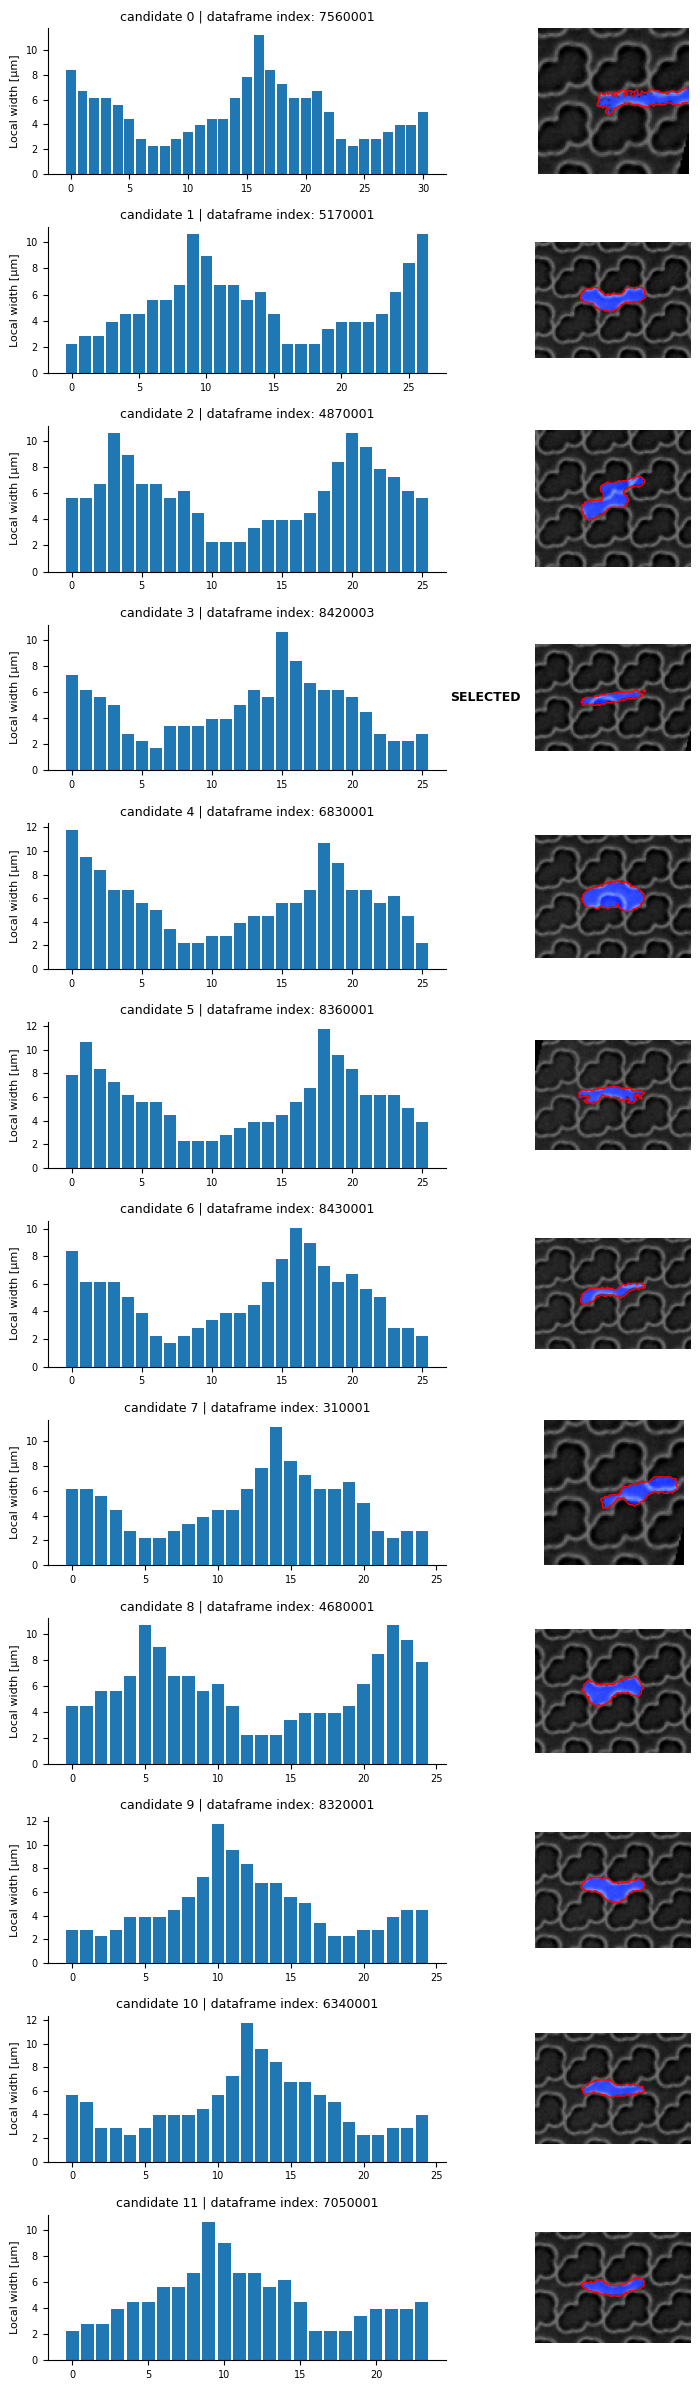

C:\Users\20212358\AppData\Local\Temp\ipykernel_22424\3432331010.py:486: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved final figure to: Figure4_rotated_pseudolocation_fingerprints.png


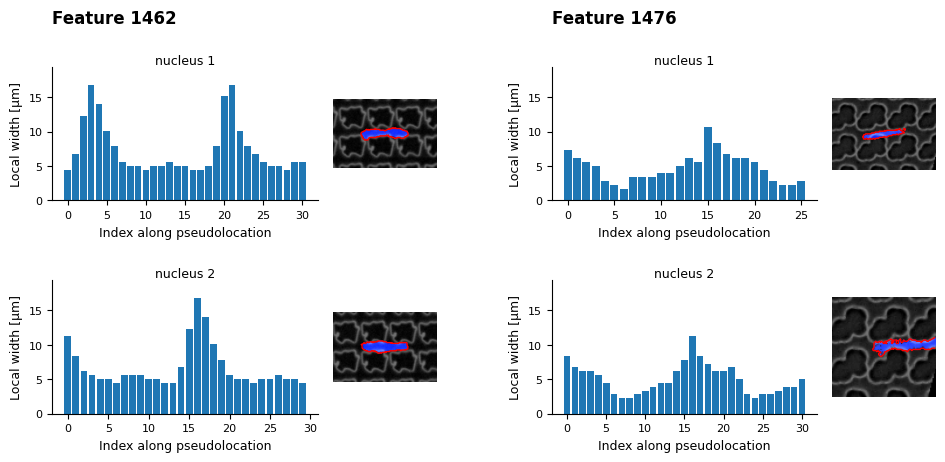

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
from scipy.ndimage import rotate as scipy_rotate
from pathlib import Path


# ============================================================
# USER SETTINGS
# ============================================================

FEATURE_1462_ROTATION_DEG = 28.34
FEATURE_1476_ROTATION_DEG = -13.47

PIXEL_SIZE_UM = 0.56

WIDTH_COL = "pseudotime_widths"
BACKGROUND_COL = "path_background"
DAPI_COL = "path_dapi"

# Look at the candidate preview and change this number if needed.
# Candidate numbering starts at 0.
CANDIDATE_NUMBER_1476_NUCLEUS1 = 3

N_CANDIDATES_TO_SHOW = 12

FINAL_OUT_PATH = "Figure4_rotated_pseudolocation_fingerprints.png"
CANDIDATE_OUT_PATH = "Figure4_1476_candidate_preview.png"


# ============================================================
# BASIC HELPERS
# ============================================================

def read_image(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Image path does not exist: {path}")
    return tifffile.imread(path)


def to_2d(img):
    img = np.asarray(img)

    if img.ndim == 2:
        return img

    if img.ndim == 3:
        if img.shape[0] <= 4:
            return img[0]
        if img.shape[-1] <= 4:
            return img[..., 0]

    raise ValueError(f"Unsupported image shape: {img.shape}")


def normalize_percentile(img, pmin=1, pmax=99):
    img = np.asarray(img, dtype=np.float32)
    lo, hi = np.percentile(img, [pmin, pmax])

    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)

    return np.clip((img - lo) / (hi - lo), 0, 1)


def parse_array(x, dtype=float):
    if isinstance(x, np.ndarray):
        return x.astype(dtype)

    if isinstance(x, list):
        return np.asarray(x, dtype=dtype)

    if isinstance(x, str):
        s = (
            x.replace("\n", " ")
             .replace(",", " ")
             .replace("[", " ")
             .replace("]", " ")
             .strip()
        )
        if s == "":
            return np.array([], dtype=dtype)
        return np.fromstring(s, sep=" ", dtype=dtype)

    if pd.isna(x):
        return np.array([], dtype=dtype)

    return np.asarray(x, dtype=dtype)


def rotate_keep_size(img, angle_deg, order=1):
    if angle_deg is None or abs(angle_deg) < 1e-9:
        return img

    img = np.asarray(img)

    if img.ndim == 2:
        return scipy_rotate(
            img,
            angle=angle_deg,
            reshape=False,
            order=order,
            mode="constant",
            cval=0
        )

    if img.ndim == 3:
        rotated_channels = [
            scipy_rotate(
                img[..., c],
                angle=angle_deg,
                reshape=False,
                order=order,
                mode="constant",
                cval=0
            )
            for c in range(img.shape[-1])
        ]
        return np.stack(rotated_channels, axis=-1)

    raise ValueError(f"Unsupported image shape for rotation: {img.shape}")


# ============================================================
# DATA LOADING
# ============================================================

def load_feature_dataframe(feature_id):
    feature_id = str(feature_id)

    candidates = [
        f"checkpoints/pseudotime_cells_clean_{feature_id}.pkl",
        f"checkpoints/pseudotime_cells_{feature_id}.pkl",
        f"pseudotime_cells_clean_{feature_id}.pkl",
        f"pseudotime_cells_{feature_id}.pkl",
    ]

    for path in candidates:
        path = Path(path)
        if path.exists():
            print(f"Loaded feature {feature_id} from: {path}")
            return pd.read_pickle(path)

    matches = list(Path(".").rglob(f"*{feature_id}*.pkl"))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find a pickle dataframe for feature {feature_id}."
        )

    print(f"Loaded feature {feature_id} from: {matches[0]}")
    return pd.read_pickle(matches[0])


def check_required_columns(df, feature_id):
    required_cols = [WIDTH_COL, BACKGROUND_COL, DAPI_COL]
    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        print(f"\nFeature {feature_id} is missing columns:")
        print(missing)

        print("\nAvailable path-like columns:")
        print([c for c in df.columns if "path" in c.lower()])

        print("\nAvailable pseudotime-like columns:")
        print([c for c in df.columns if "pseudo" in c.lower()])

        raise KeyError(f"Missing required columns in feature {feature_id}: {missing}")


try:
    df1462
except NameError:
    df1462 = load_feature_dataframe(1462)

try:
    df1476
except NameError:
    df1476 = load_feature_dataframe(1476)

check_required_columns(df1462, 1462)
check_required_columns(df1476, 1476)


# ============================================================
# IMAGE CROP HELPERS
# ============================================================

def make_bf_dapi_overlay(
    background,
    dapi,
    invert_background=True,
    background_weight=0.45,
    dapi_gain=2.5
):
    bg = normalize_percentile(background, 1, 99)

    if invert_background:
        bg = 1.0 - bg

    dapi_norm = normalize_percentile(dapi, 1, 99.8)
    dapi_disp = np.clip(dapi_norm * dapi_gain, 0, 1)

    rgb = np.zeros((*bg.shape, 3), dtype=np.float32)

    rgb[..., 0] = bg * background_weight
    rgb[..., 1] = bg * background_weight
    rgb[..., 2] = bg * background_weight

    rgb[..., 2] += dapi_disp
    rgb[..., 1] += dapi_disp * 0.15
    rgb[..., 0] += dapi_disp * 0.05

    return np.clip(rgb, 0, 1), dapi_disp


def crop_around_signal(img, signal, threshold=0.15, pad=35):
    mask = signal > threshold
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return img, signal

    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, img.shape[0])

    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, img.shape[1])

    return img[y0:y1, x0:x1], signal[y0:y1, x0:x1]


def make_rotated_nucleus_crop(
    row,
    rotation_deg=0,
    crop_threshold=0.15,
    crop_pad=35,
    invert_background=True,
    background_weight=0.45,
    dapi_gain=2.5
):
    bg = to_2d(read_image(row[BACKGROUND_COL]))
    dapi = to_2d(read_image(row[DAPI_COL]))

    if bg.shape != dapi.shape:
        raise ValueError(f"Background and DAPI shape mismatch: {bg.shape} vs {dapi.shape}")

    overlay, dapi_signal = make_bf_dapi_overlay(
        background=bg,
        dapi=dapi,
        invert_background=invert_background,
        background_weight=background_weight,
        dapi_gain=dapi_gain
    )

    overlay_rot = rotate_keep_size(overlay, rotation_deg, order=1)
    dapi_rot = rotate_keep_size(dapi_signal, rotation_deg, order=1)

    crop_overlay, crop_signal = crop_around_signal(
        overlay_rot,
        dapi_rot,
        threshold=crop_threshold,
        pad=crop_pad
    )

    return crop_overlay, crop_signal


# ============================================================
# EXAMPLE SELECTION
# ============================================================

def profile_length(x):
    return len(parse_array(x, dtype=float))


def get_valid_examples(df):
    df = df.copy()
    df["_profile_length"] = df[WIDTH_COL].apply(profile_length)

    df = df[
        (df["_profile_length"] > 5)
        & df[BACKGROUND_COL].notna()
        & df[DAPI_COL].notna()
    ].copy()

    df = df[
        df[BACKGROUND_COL].apply(lambda p: Path(p).exists())
        & df[DAPI_COL].apply(lambda p: Path(p).exists())
    ].copy()

    return df.sort_values("_profile_length", ascending=False)


valid1462 = get_valid_examples(df1462)
valid1476 = get_valid_examples(df1476)

if len(valid1462) < 2:
    raise ValueError("Not enough valid nuclei for feature 1462.")

if len(valid1476) < 2:
    raise ValueError("Not enough valid nuclei for feature 1476.")

# Keep automatic 1462 examples.
df1462_examples = valid1462.head(2)

# Candidate list for 1476.
df1476_candidates = valid1476.head(N_CANDIDATES_TO_SHOW)

if CANDIDATE_NUMBER_1476_NUCLEUS1 >= len(df1476_candidates):
    raise ValueError(
        f"CANDIDATE_NUMBER_1476_NUCLEUS1={CANDIDATE_NUMBER_1476_NUCLEUS1} "
        f"but only {len(df1476_candidates)} candidates are available."
    )

# Replace nucleus 1 for 1476 with selected candidate.
# Keep nucleus 2 as the second automatically selected valid example,
# unless it is the same as nucleus 1.
selected_1476_nucleus1 = df1476_candidates.iloc[[CANDIDATE_NUMBER_1476_NUCLEUS1]]

remaining_1476 = valid1476.drop(index=selected_1476_nucleus1.index)
selected_1476_nucleus2 = remaining_1476.iloc[[0]]

df1476_examples = pd.concat([selected_1476_nucleus1, selected_1476_nucleus2])


print("Selected 1462 dataframe indices:", list(df1462_examples.index))
print("Selected 1476 dataframe indices:", list(df1476_examples.index))
print("Selected 1476 nucleus 1 candidate number:", CANDIDATE_NUMBER_1476_NUCLEUS1)


# ============================================================
# CANDIDATE PREVIEW FOR 1476
# ============================================================

def plot_1476_candidate_preview():
    n = len(df1476_candidates)

    fig, axes = plt.subplots(
        n,
        2,
        figsize=(7.2, 2.0 * n),
        gridspec_kw={"width_ratios": [3.2, 1.25]}
    )

    if n == 1:
        axes = np.array([axes])

    for i, (idx, row) in enumerate(df1476_candidates.iterrows()):
        ax_bar, ax_img = axes[i]

        widths = parse_array(row[WIDTH_COL], dtype=float) * PIXEL_SIZE_UM

        ax_bar.bar(np.arange(len(widths)), widths, width=0.85)
        ax_bar.set_ylabel("Local width [µm]", fontsize=8)
        ax_bar.set_title(f"candidate {i} | dataframe index: {idx}", fontsize=9)
        ax_bar.tick_params(axis="both", labelsize=7)
        ax_bar.spines["top"].set_visible(False)
        ax_bar.spines["right"].set_visible(False)

        crop_overlay, crop_signal = make_rotated_nucleus_crop(
            row=row,
            rotation_deg=FEATURE_1476_ROTATION_DEG,
            crop_threshold=0.15,
            crop_pad=35
        )

        ax_img.imshow(crop_overlay)
        ax_img.contour(
            crop_signal > 0.15,
            levels=[0.5],
            colors="red",
            linewidths=1.0
        )
        ax_img.axis("off")

        if i == CANDIDATE_NUMBER_1476_NUCLEUS1:
            ax_bar.text(
                1.01,
                0.5,
                "SELECTED",
                transform=ax_bar.transAxes,
                fontsize=9,
                fontweight="bold",
                va="center"
            )

    fig.tight_layout()
    fig.savefig(CANDIDATE_OUT_PATH, dpi=300, bbox_inches="tight")
    print(f"Saved candidate preview to: {CANDIDATE_OUT_PATH}")

    return fig


candidate_fig = plot_1476_candidate_preview()
plt.show()


# ============================================================
# FINAL FIGURE
# ============================================================

def plot_pseudolocation_fingerprint_figure(
    panels,
    crop_threshold=0.15,
    crop_pad=35,
    out_path=None,
    dpi=300
):
    n_panels = len(panels)
    n_rows = max(len(p["df"]) for p in panels)

    fig = plt.figure(figsize=(5.7 * n_panels, 2.25 * n_rows))
    outer = fig.add_gridspec(1, n_panels, wspace=0.30)

    all_widths = []
    for panel in panels:
        for _, row in panel["df"].iterrows():
            widths = parse_array(row[WIDTH_COL], dtype=float) * PIXEL_SIZE_UM
            if len(widths) > 0:
                all_widths.append(widths)

    ymax = np.nanmax([np.nanmax(w) for w in all_widths])
    ylimit = (0, ymax * 1.15)

    for p_idx, panel in enumerate(panels):
        df = panel["df"]
        feature = panel["feature"]
        rotation_deg = panel["rotation_deg"]

        inner = outer[p_idx].subgridspec(
            n_rows,
            2,
            width_ratios=[3.2, 1.25],
            wspace=0.08,
            hspace=0.60
        )

        for r_idx, (_, row) in enumerate(df.iterrows()):
            ax_bar = fig.add_subplot(inner[r_idx, 0])
            ax_img = fig.add_subplot(inner[r_idx, 1])

            widths = parse_array(row[WIDTH_COL], dtype=float) * PIXEL_SIZE_UM
            x = np.arange(len(widths))

            ax_bar.bar(x, widths, width=0.85)
            ax_bar.set_title(f"nucleus {r_idx + 1}", fontsize=9, pad=2)
            ax_bar.set_xlabel("Index along pseudolocation", fontsize=9)
            ax_bar.set_ylabel("Local width [µm]", fontsize=9)
            ax_bar.set_ylim(*ylimit)
            ax_bar.tick_params(axis="both", labelsize=8)
            ax_bar.spines["top"].set_visible(False)
            ax_bar.spines["right"].set_visible(False)

            crop_overlay, crop_signal = make_rotated_nucleus_crop(
                row=row,
                rotation_deg=rotation_deg,
                crop_threshold=crop_threshold,
                crop_pad=crop_pad
            )

            ax_img.imshow(crop_overlay)
            ax_img.contour(
                crop_signal > crop_threshold,
                levels=[0.5],
                colors="red",
                linewidths=1.0
            )
            ax_img.axis("off")

            if r_idx == 0:
                ax_bar.text(
                    0.0,
                    1.30,
                    f"Feature {feature}",
                    transform=ax_bar.transAxes,
                    fontsize=12,
                    fontweight="bold",
                    ha="left",
                    va="bottom"
                )

    fig.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved final figure to: {out_path}")

    return fig


final_fig = plot_pseudolocation_fingerprint_figure(
    panels=[
        {
            "df": df1462_examples,
            "feature": "1462",
            "rotation_deg": FEATURE_1462_ROTATION_DEG
        },
        {
            "df": df1476_examples,
            "feature": "1476",
            "rotation_deg": FEATURE_1476_ROTATION_DEG
        }
    ],
    crop_threshold=0.15,
    crop_pad=35,
    out_path=FINAL_OUT_PATH,
    dpi=300
)

plt.show()

Saved 1462 candidate preview to: Figure4_1462_candidate_preview.png

Candidate dataframe indices for 1462:
[7190001, 4320001, 5740001, 4630001, 3790001, 1800002, 4950001, 5930001, 2310001, 3300001, 2020001, 3860001, 2690002, 2390001, 3220001, 2320001, 1380001, 2300001, 2870001, 5760001]


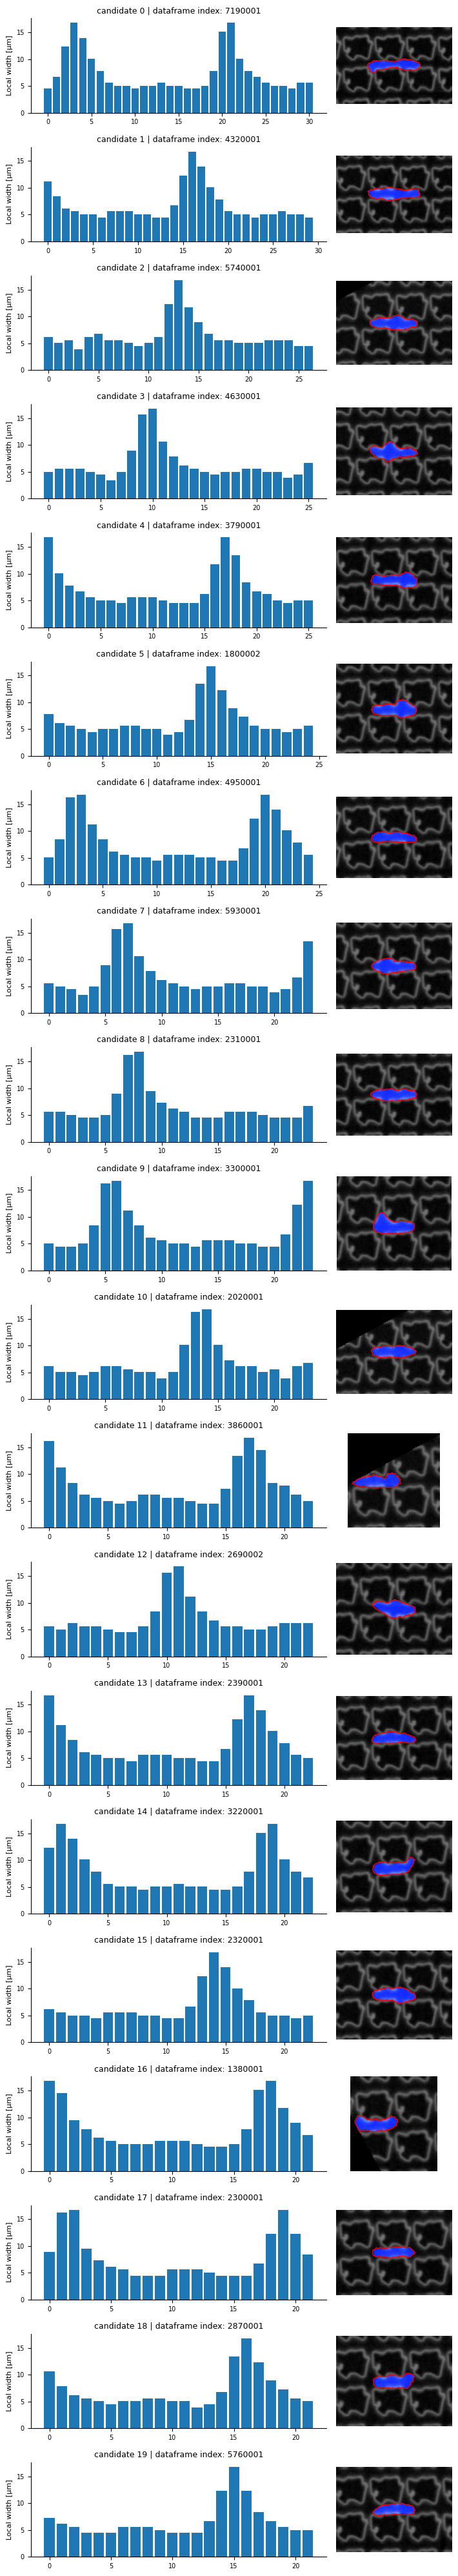

In [5]:
# ============================================================
# Explore candidate nuclei for feature 1462
# Requires that the previous full plotting/helper code has been run.
# ============================================================

FEATURE_1462_ROTATION_DEG = 28.34
N_CANDIDATES_1462_TO_SHOW = 20
CANDIDATE_1462_OUT_PATH = "Figure4_1462_candidate_preview.png"


def plot_1462_candidate_preview(
    df1462,
    n_candidates=20,
    rotation_deg=28.34,
    crop_threshold=0.15,
    crop_pad=35,
):
    valid1462 = get_valid_examples(df1462)
    df1462_candidates = valid1462.head(n_candidates)

    n = len(df1462_candidates)

    fig, axes = plt.subplots(
        n,
        2,
        figsize=(7.2, 2.0 * n),
        gridspec_kw={"width_ratios": [3.2, 1.25]}
    )

    if n == 1:
        axes = np.array([axes])

    for i, (idx, row) in enumerate(df1462_candidates.iterrows()):
        ax_bar, ax_img = axes[i]

        widths = parse_array(row[WIDTH_COL], dtype=float) * PIXEL_SIZE_UM

        ax_bar.bar(np.arange(len(widths)), widths, width=0.85)
        ax_bar.set_ylabel("Local width [µm]", fontsize=8)
        ax_bar.set_title(f"candidate {i} | dataframe index: {idx}", fontsize=9)
        ax_bar.tick_params(axis="both", labelsize=7)
        ax_bar.spines["top"].set_visible(False)
        ax_bar.spines["right"].set_visible(False)

        crop_overlay, crop_signal = make_rotated_nucleus_crop(
            row=row,
            rotation_deg=rotation_deg,
            crop_threshold=crop_threshold,
            crop_pad=crop_pad
        )

        ax_img.imshow(crop_overlay)
        ax_img.contour(
            crop_signal > crop_threshold,
            levels=[0.5],
            colors="red",
            linewidths=1.0
        )
        ax_img.axis("off")

    fig.tight_layout()
    fig.savefig(CANDIDATE_1462_OUT_PATH, dpi=300, bbox_inches="tight")
    print(f"Saved 1462 candidate preview to: {CANDIDATE_1462_OUT_PATH}")

    print("\nCandidate dataframe indices for 1462:")
    print(list(df1462_candidates.index))

    return df1462_candidates, fig


df1462_candidates, fig1462_candidates = plot_1462_candidate_preview(
    df1462=df1462,
    n_candidates=N_CANDIDATES_1462_TO_SHOW,
    rotation_deg=FEATURE_1462_ROTATION_DEG,
    crop_threshold=0.15,
    crop_pad=35
)

plt.show()

C:\Users\20212358\AppData\Local\Temp\ipykernel_22424\3432331010.py:486: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved final figure to: Figure4_rotated_pseudolocation_fingerprints_FINAL.png


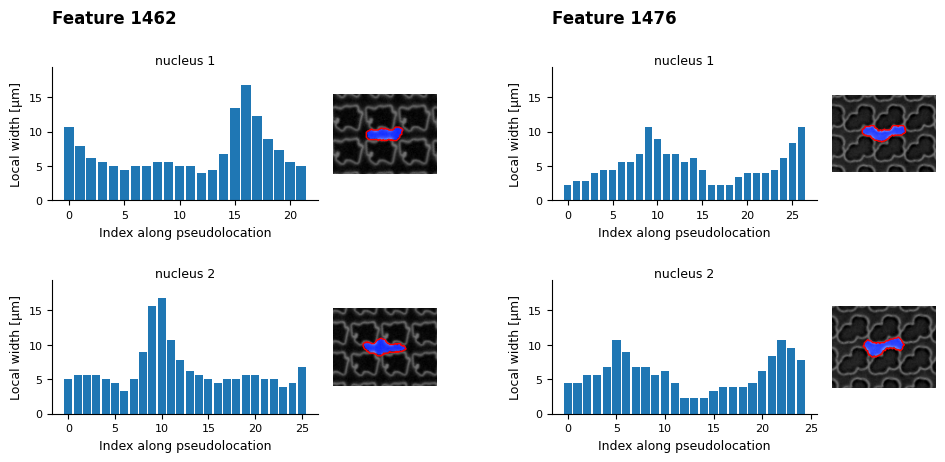

In [6]:
df1462_examples = df1462.loc[[2870001, 4630001]]
df1476_examples = df1476.loc[[5170001, 4680001]]

final_fig = plot_pseudolocation_fingerprint_figure(
    panels=[
        {
            "df": df1462_examples,
            "feature": "1462",
            "rotation_deg": FEATURE_1462_ROTATION_DEG
        },
        {
            "df": df1476_examples,
            "feature": "1476",
            "rotation_deg": FEATURE_1476_ROTATION_DEG
        }
    ],
    crop_threshold=0.15,
    crop_pad=35,
    out_path="Figure4_rotated_pseudolocation_fingerprints_FINAL.png",
    dpi=300
)

plt.show()